<a href="https://colab.research.google.com/github/Prajakta1926/Canvas-Editor/blob/main/surplus_duration_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
np.random.seed(0)
N=10000
horizon_years=40

In [ ]:
params=pd.read_excel("retirement.csv.xlsx")

In [ ]:
def get_param(df, param_code_name, cast_type=str, source_column="Value/Range"):
    param_map = {
        "Initial_assets":        "Initial assets",
        "Annual_expenses":       "Annual expenses",
        "Inflation_Rate":        "Inflation Rate",
        "weight_debt":           "Debt",
        "weight_equity":         "Equity",
        "weight_gold":           "Gold",
        "weight_cash":           "Cash",
        "Withdrawal_Rate":       "Withdrawal Rate",
        "mean_return_debt":      "Mean Return Debt",
        "mean_return_equity":    "Mean Return Equity",
        "mean_return_gold":      "Mean Return Gold",
        "mean_return_cash":      "Mean Return Cash",
        "std_dev_return_debt":   "Std Dev Return Debt",
        "std_dev_return_equity": "Std Dev Return Equity",
        "std_dev_return_gold":   "Std Dev Return Gold",
        "std_dev_return_cash":   "Std Dev Return Cash",
        "number_of_paths":       "Number of paths",
    }

    actual_name = param_map.get(param_code_name, param_code_name)

    row = df[df["Parameter"] == actual_name]
    if row.empty:
        raise ValueError(
            f"Parameter '{param_code_name}' (looked for '{actual_name}') "
            "not found in the DataFrame."
        )

    value = row[source_column].iloc[0]

    if pd.isna(value):
        if cast_type in (float, int):
            return np.nan
        return str(np.nan)

    try:
        return cast_type(value)
    except ValueError:
        raise ValueError(
            f"Could not convert value '{value}' for parameter '{param_code_name}' "
            f"from column '{source_column}' to type {cast_type.__name__}."
        )



In [ ]:
starting_portfolio_value=35000000
starting_annual_expenses=840000

In [ ]:
print("starting_portfolio_value:", starting_portfolio_value)
print("starting_annual_expenses:", starting_annual_expenses)
print("inflation_min/max:", min_annual_inflation_rate, max_annual_inflation_rate)
print("asset_weights:", asset_weights)
print("asset_mean_returns:", asset_mean_returns)
print("asset_return_std_devs:", asset_return_std_devs)
print("withdrawal_rate:", initial_withdrawal_rate)
print("horizon:", retirement_horizon_years)


starting_portfolio_value: 35000000
starting_annual_expenses: 840000
inflation_min/max: 0.03 0.07
asset_weights: [0.65 0.25 0.07 0.03]
asset_mean_returns: [0.06 0.11 0.07 0.03]
asset_return_std_devs: [0.06 0.11 0.1  0.  ]
withdrawal_rate: 0.04
horizon: 40


In [ ]:
survival_indicator = np.zeros(number_of_simulated_paths, dtype=int)
year_of_portfolio_ruin = np.full(number_of_simulated_paths,
                                 retirement_horizon_years + 1,
                                 dtype=int)

for path_index in range(number_of_simulated_paths):
    portfolio_value = starting_portfolio_value
    annual_expense  = starting_annual_expenses
    portfolio_ruined = False

    for year in range(1, retirement_horizon_years + 1):
        inflation_rate = (
            min_annual_inflation_rate
            + (max_annual_inflation_rate - min_annual_inflation_rate) * np.random.rand()
        )

        z = np.random.randn(4)
        asset_returns = asset_mean_returns + asset_return_std_devs * z
        portfolio_return = np.dot(asset_weights, asset_returns)

        annual_expense *= (1.0 + inflation_rate)
        portfolio_value = (portfolio_value - annual_expense) * (1.0 + portfolio_return)

        if portfolio_value <= 0:
            portfolio_ruined = True
            year_of_portfolio_ruin[path_index] = year
            break

    if not portfolio_ruined:
        survival_indicator[path_index] = 1

In [ ]:
survival_indicator = np.array(survival_indicator, dtype=int)
estimated_survival_probability = survival_indicator.mean()

monte_carlo_standard_error = np.sqrt(
    estimated_survival_probability * (1 - estimated_survival_probability)
    / number_of_simulated_paths
)

confidence_interval_lower = (
    estimated_survival_probability - 1.96 * monte_carlo_standard_error
)
confidence_interval_upper = (
    estimated_survival_probability + 1.96 * monte_carlo_standard_error
)

In [ ]:
print("Monte Carlo results")
print("Horizon (years):", retirement_horizon_years)
print("Number of simulated paths:", number_of_simulated_paths)

print("Estimated survival probability: {:.4f}".format(
    estimated_survival_probability)
)

print("Monte Carlo standard error: {:.6f}".format(
    monte_carlo_standard_error)
)

print("Approximate 95% CI: [{:.4f}, {:.4f}]".format(
    confidence_interval_lower,
    confidence_interval_upper
))

Monte Carlo results
Horizon (years): 40
Number of simulated paths: 20000
Estimated survival probability: 0.9861
Monte Carlo standard error: 0.000828
Approximate 95% CI: [0.9845, 0.9877]


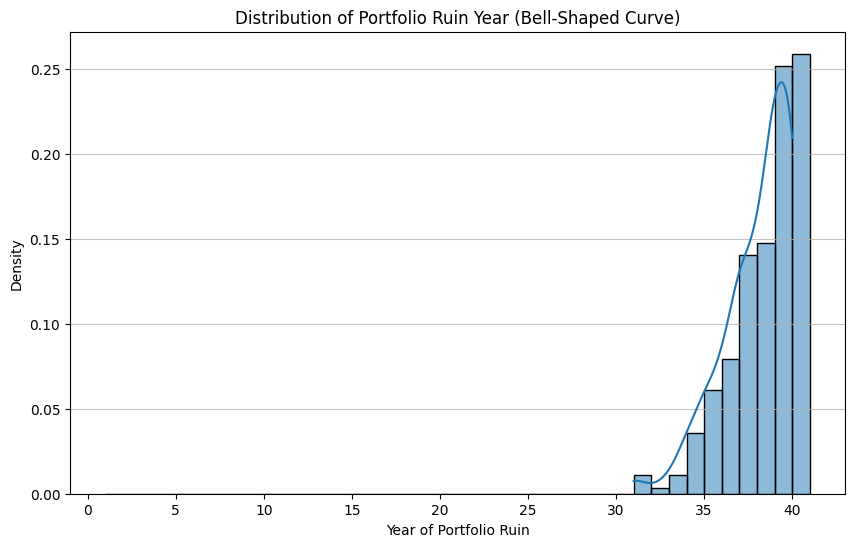

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out paths where the portfolio did not ruin (year_of_portfolio_ruin == retirement_horizon_years + 1)
ruin_years = year_of_portfolio_ruin[year_of_portfolio_ruin <= retirement_horizon_years]

plt.figure(figsize=(10, 6))
sns.histplot(ruin_years, bins=range(1, retirement_horizon_years + 2), kde=True, stat='density')
plt.title('Distribution of Portfolio Ruin Year (Bell-Shaped Curve)')
plt.xlabel('Year of Portfolio Ruin')
plt.ylabel('Density')
plt.xticks(range(0, retirement_horizon_years + 1, 5))
plt.grid(axis='y', alpha=0.75)
plt.show()